In [1]:
import dm_control.suite.common as common
from dm_control import mujoco
from dm_control import viewer
from PIL import Image

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card4: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

/home/rdkeller/miniconda3/envs/fishies/lib/python3.12/site-packages/glfw/__init__.py:914: GLFWError: (65544) b'X11: The DISPLAY environment variable is missing'
  warnings.warn(message, GLFWError)


In [2]:
!pwd
import os, sys
os.chdir('/home/rdkeller/zebrafish_agent/')
#os.chdir('/Users/reecekeller/Documents/neuroagents/zebrafish_agent/')
os.environ["MUJOCO_GL"] = "egl"
!pwd

/home/rdkeller/zebrafish_agent/zfa_rl_agent/core/environments


/home/rdkeller/zebrafish_agent


In [3]:
from zfa_rl_agent.core.environments.zebrafish import swimmer_dm
from zfa_rl_agent.core.environments.grating import swimmer_grating_venv, swimmer_grating_dm
from zfa_rl_agent.core.environments.curiosity_venv_wrapper import curiosity_venv


In [4]:
env = swimmer_grating_venv(parallel=0, 
                   use_ray=0, 
                   n_envs=1, 
                   seed=12345, 
                   monitor_dir=None, 
                   grating_speed=0.01)

curious_env = curiosity_venv(env, 345, 5)


2025-04-01 14:53:15,021 - zfa_rl_agent.core.utils.logger - INFO - Vectorizing with DummyVecEnv
INFO:zfa_rl_agent.core.utils.logger:Vectorizing with DummyVecEnv


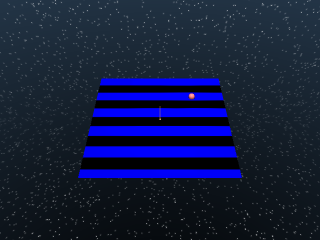

In [5]:
dm_env = swimmer_grating_dm()
Image.fromarray(dm_env.physics.render())

In [6]:
from zfa_rl_agent.core.agent.PPO.rPPO import PPO as rPPO
model = rPPO("MultiModalPolicy", curious_env)
model.learn(1)


345


In [7]:
asd

/home/rdkeller/miniconda3/envs/fishies/lib/python3.12/site-packages/executing/executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
/home/rdkeller/miniconda3/envs/fishies/lib/python3.12/site-packages/executing/executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
/home/rdkeller/miniconda3/envs/fishies/lib/python3.12/ast.py:587: DeprecationWarning: Attribute s is deprecated and will be removed in Python 3.14; use value instead
  return Constant(*args, **kwargs)
/home/rdkeller/miniconda3/envs/fishies/lib/python3.12/site-packages/executing/executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
/home/rdkeller/miniconda3/envs/fishies/lib/python3.12/ast.py:587: DeprecationWarning: Attribute s is deprecated and

NameError: name 'asd' is not defined

In [8]:
import imageio
import numpy as np
images = []
obs = model.env.reset()
img = model.env.render(mode="rgb_array")
for i in range(350):
    images.append(img)
    action, _ = model.predict(obs)
    obs, _, _ ,_ = model.env.step(action)
    img = model.env.render(mode="rgb_array")

imageio.mimsave("grating.gif", [np.array(img) for i, img in enumerate(images) if i%2 == 0])

In [ ]:
model.env.venv.action_space

Box(-1.0, 1.0, (5,), float64)

In [ ]:
env.reset()
print(env.observation_spec())
# Define a zero action policy
zero_action = np.zeros(action_spec.shape)
random_action = np.random.uniform(action_spec.minimum, action_spec.maximum, action_spec.shape)
# Step the environment with zero action
time_step = env.step(zero_action)
for _ in range(10):
    time_step = env.step(zero_action)[0]
    to_target = time_step['to_target']
    mjdata = env.physics.data
    print(mjdata.qfrc_fluid, '\n', mjdata.qfrc_applied, '\n', mjdata.xfrc_applied, '\n', time_step['to_target'])
    # Render the environment
    pixels = env.physics.render()
    image = Image.fromarray(pixels)
    display(image)

/home/rdkeller/miniconda3/envs/fishies/lib/python3.12/site-packages/executing/executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
/home/rdkeller/miniconda3/envs/fishies/lib/python3.12/site-packages/executing/executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
/home/rdkeller/miniconda3/envs/fishies/lib/python3.12/ast.py:587: DeprecationWarning: Attribute s is deprecated and will be removed in Python 3.14; use value instead
  return Constant(*args, **kwargs)
/home/rdkeller/miniconda3/envs/fishies/lib/python3.12/site-packages/executing/executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
/home/rdkeller/miniconda3/envs/fishies/lib/python3.12/ast.py:587: DeprecationWarning: Attribute s is deprecated and

AttributeError: 'DummyVecEnv' object has no attribute 'observation_spec'

In [ ]:
from kelp_forest import generate_xml

In [ ]:
from PIL import Image
import io

xml, assets = generate_xml(6)
physics = mujoco.Physics.from_xml_string(xml)
# Render the physics to an image with specified resolution
pixels = physics.render(height=480, width=640)
image = Image.fromarray(pixels)
pdf_bytes = io.BytesIO()
# image.save(pdf_bytes, format='PDF')
# with open('rendered_image.pdf', 'wb') as f:
#     f.write(pdf_bytes.getvalue())


In [ ]:
from environment_factory import make_swimmer_env

ModuleNotFoundError: No module named 'zfa_rl_agent'

In [ ]:
env = make_swimmer_env()

Number of segments: 5
Size of body: 0.54
(45,)


In [ ]:
obs = env.reset()
obs[0]['joints'].shape 

(45,)


(5,)

/home/rdkeller/miniconda3/envs/fishies/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
/home/rdkeller/miniconda3/envs/fishies/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
/home/rdkeller/miniconda3/envs/fishies/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


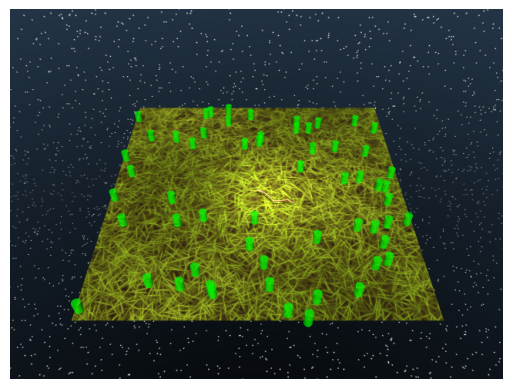

In [ ]:
import matplotlib.pyplot as plt

# Render the environment to an image
pixels = env.physics.render(height=480, width=640)

# Display the image
plt.imshow(pixels)
plt.axis('off')  # Hide the axis
plt.show()

In [ ]:
from dm_control import suite

# Load the swimmer environment
swimmer_env = suite.load(domain_name="swimmer", task_name="swimmer6")

obs = swimmer_env.reset()
obs[-1]['joints'].shape

(5,)